<a href="https://colab.research.google.com/github/VinceGarcia11/Melbourne_Housing/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.tools.tools as stattools
from sklearn.tree import DecisionTreeClassifier, export_graphviz, DecisionTreeRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.tools.tools as stattools
from sklearn.ensemble import RandomForestRegressor

#reading the data
url = "https://raw.githubusercontent.com/VinceGarcia11/Melbourne_Housing/refs/heads/main/melb_data.csv"
house = pd.read_csv(url)
house.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/3/2017,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


**Exploratory Data Analysis**

In [118]:
house = house.dropna()
house = house[(house['BuildingArea'] >= 20)]

In [119]:
categorical = house.select_dtypes(include =['object', 'category']).columns
categorical

Index(['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea',
       'Regionname'],
      dtype='object')

In [120]:
numerical = house.select_dtypes(include = ['int64', 'float64']).columns
numerical

Index(['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude',
       'Propertycount'],
      dtype='object')

In [121]:
force_categorical = ["Postcode", "YearBuilt", "Propertycount"]
house[force_categorical] = house[force_categorical].astype('category')
categorical = house.select_dtypes(include =['object', 'category']).columns
categorical


Index(['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'Postcode',
       'YearBuilt', 'CouncilArea', 'Regionname', 'Propertycount'],
      dtype='object')

In [122]:
numeric_cols = house.select_dtypes(include = ['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in force_categorical]
numeric_cols

['Rooms',
 'Price',
 'Distance',
 'Bedroom2',
 'Bathroom',
 'Car',
 'Landsize',
 'BuildingArea',
 'Lattitude',
 'Longtitude']

In [123]:
numeric_summary = house[numeric_cols].describe()
numeric_summary

,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Lattitude,Longtitude
count,6152.000000,6.152000e+03,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000
mean,2.932705,1.070074e+06,9.757754,2.902796,1.576886,1.574610,472.200260,142.544266,-37.807887,144.990125
std,0.972399,6.758482e+05,5.618523,0.971373,0.711934,0.931725,899.905235,90.419551,0.075950,0.099220
min,1.000000,1.310000e+05,0.000000,0.000000,1.000000,0.000000,0.000000,21.000000,-38.164920,144.542370
25%,2.000000,6.200000e+05,5.900000,2.000000,1.000000,1.000000,153.000000,92.000000,-37.855490,144.926130
50%,3.000000,8.800000e+05,9.100000,3.000000,1.000000,1.000000,376.000000,124.000000,-37.802200,144.995755
75%,4.000000,1.328000e+06,12.400000,3.000000,2.000000,2.000000,629.000000,170.000000,-37.758188,145.052800
max,8.000000,9.000000e+06,47.400000,9.000000,8.000000,10.000000,37000.000000,3112.000000,-37.457090,145.526350


In [124]:
# Since there is clearly an outlier where BuildingArea = 44515, while the max Landsize is 44500, I am removing this row from the dataset

house = house.drop(house[house['BuildingArea'] == 44515].index)
numeric_summary = house[numeric_cols].describe()
numeric_summary

# There are still outliers, but none that look quite as egregious


,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Lattitude,Longtitude
count,6152.000000,6.152000e+03,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000,6152.000000
mean,2.932705,1.070074e+06,9.757754,2.902796,1.576886,1.574610,472.200260,142.544266,-37.807887,144.990125
std,0.972399,6.758482e+05,5.618523,0.971373,0.711934,0.931725,899.905235,90.419551,0.075950,0.099220
min,1.000000,1.310000e+05,0.000000,0.000000,1.000000,0.000000,0.000000,21.000000,-38.164920,144.542370
25%,2.000000,6.200000e+05,5.900000,2.000000,1.000000,1.000000,153.000000,92.000000,-37.855490,144.926130
50%,3.000000,8.800000e+05,9.100000,3.000000,1.000000,1.000000,376.000000,124.000000,-37.802200,144.995755
75%,4.000000,1.328000e+06,12.400000,3.000000,2.000000,2.000000,629.000000,170.000000,-37.758188,145.052800
max,8.000000,9.000000e+06,47.400000,9.000000,8.000000,10.000000,37000.000000,3112.000000,-37.457090,145.526350


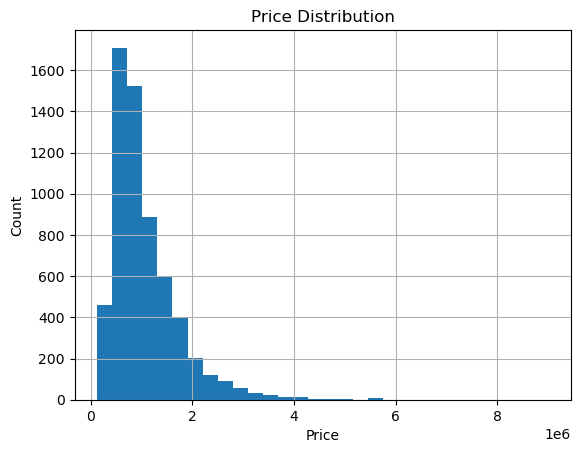

In [125]:
house["Price"].hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

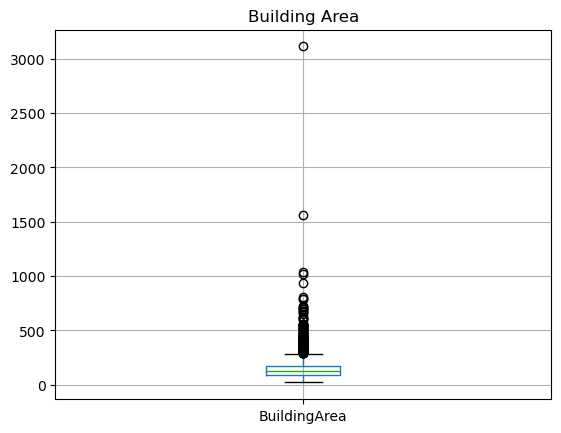

In [126]:
house[['BuildingArea']].boxplot()
plt.title("Building Area")
plt.show()

In [127]:
house.describe(include=['object', 'category'])

,Suburb,Address,Type,Method,SellerG,Date,Postcode,YearBuilt,CouncilArea,Regionname,Propertycount
count,6152,6152,6152,6152,6152,6152,6152,6152.0,6152,6152,6152
unique,287,6073,3,5,202,51,185,134.0,31,8,284
top,Reservoir,36 Aberfeldie St,h,S,Nelson,27/05/2017,3121,1970.0,Moreland,Southern Metropolitan,21650
freq,152,3,4074,3931,761,225,155,595.0,654,2151,152


In [128]:
# Define categorical_cols first
categorical_cols = house.select_dtypes(include=['object', 'category']).columns.tolist() #suggested by Gemini AI

house = house.drop(columns=['Address', 'Method', 'SellerG', 'Date', 'Propertycount'])
categorical_cols = [col for col in categorical_cols if col not in ['Address', 'Method', 'SellerG', 'Date', 'Propertycount']]

Analysis for column: Suburb

Frequency counts:
Suburb
Reservoir           152
Richmond            137
Brunswick           124
Bentleigh East      106
Coburg              101
                   ... 
Ardeer                1
Brookfield            1
Cranbourne North      1
Emerald               1
Whittlesea            1
Name: count, Length: 287, dtype: int64
Mode: ['Reservoir']

Unique categories: 287



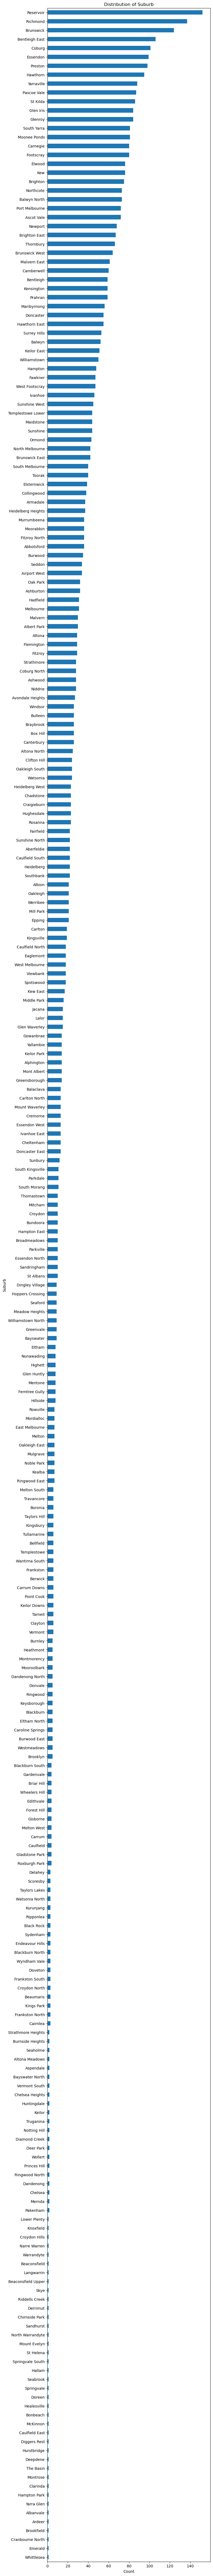

Analysis for column: Type

Frequency counts:
Type
h    4074
u    1495
t     583
Name: count, dtype: int64
Mode: ['h']

Unique categories: 3



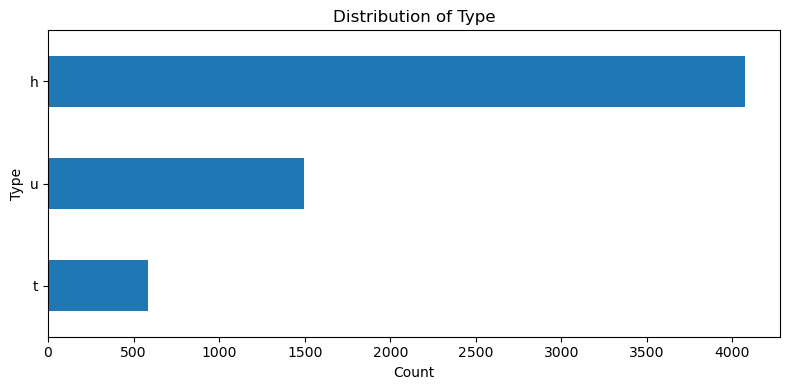

Analysis for column: Postcode

Frequency counts:
Postcode
3121    155
3073    152
3046    147
3032    134
3040    134
       ... 
3805      1
3808      1
3807      1
3910      1
3976      1
Name: count, Length: 185, dtype: int64
Mode: [3121]

Unique categories: 185



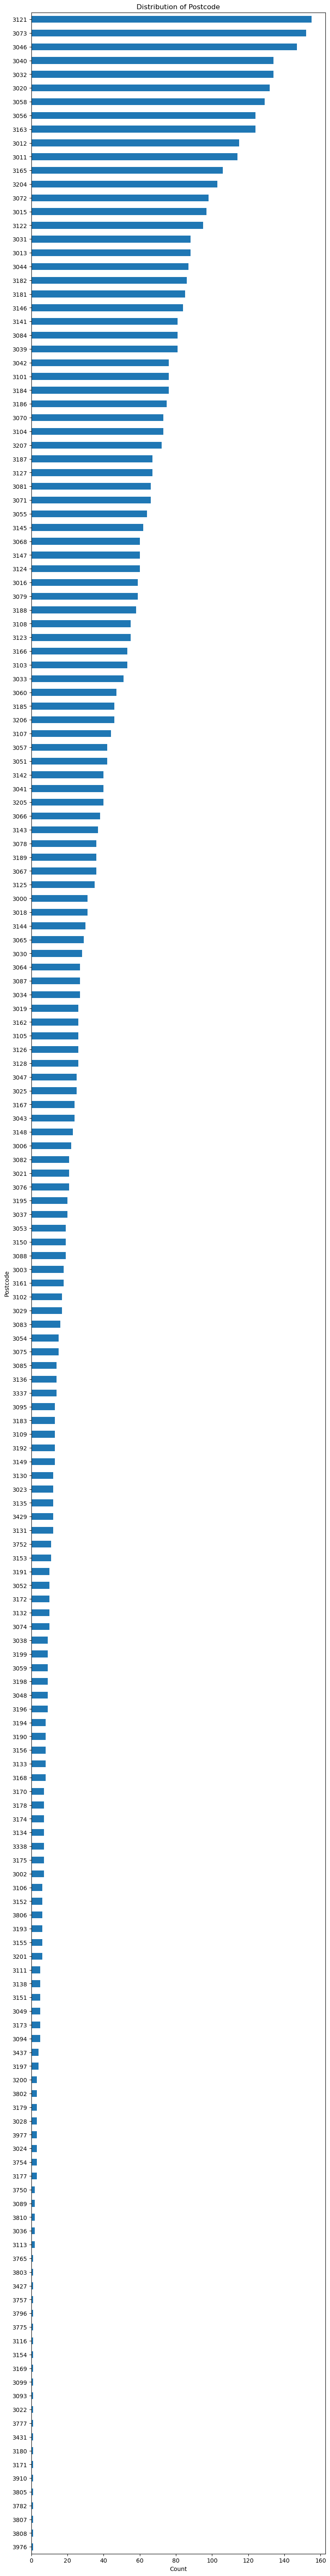

Analysis for column: YearBuilt

Frequency counts:
YearBuilt
1970.0    595
1960.0    550
1950.0    453
1900.0    269
1930.0    232
         ... 
1902.0      1
1907.0      1
1906.0      1
1964.0      1
2018.0      1
Name: count, Length: 134, dtype: int64
Mode: [1970.0]

Unique categories: 134



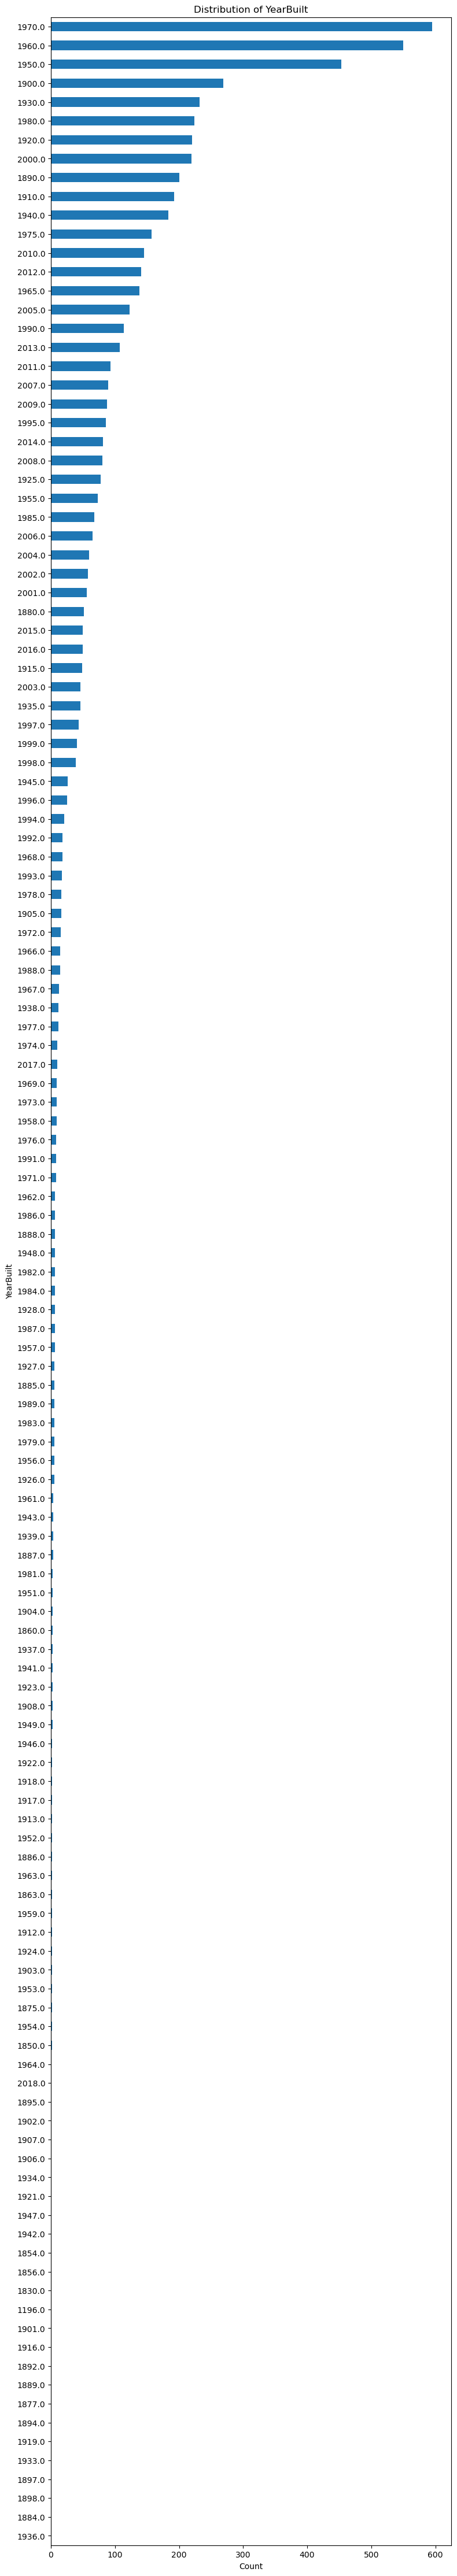

Analysis for column: CouncilArea

Frequency counts:
CouncilArea
Moreland             654
Boroondara           573
Moonee Valley        504
Darebin              427
Glen Eira            425
Maribyrnong          394
Yarra                337
Port Phillip         333
Stonnington          331
Banyule              276
Melbourne            239
Bayside              220
Hobsons Bay          219
Brimbank             193
Monash               172
Manningham           150
Whitehorse           138
Kingston             111
Hume                  97
Whittlesea            89
Wyndham               47
Melton                42
Knox                  41
Maroondah             35
Frankston             30
Greater Dandenong     21
Nillumbik             18
Casey                 16
Yarra Ranges          10
Macedon Ranges         5
Cardinia               5
Name: count, dtype: int64
Mode: ['Moreland']

Unique categories: 31



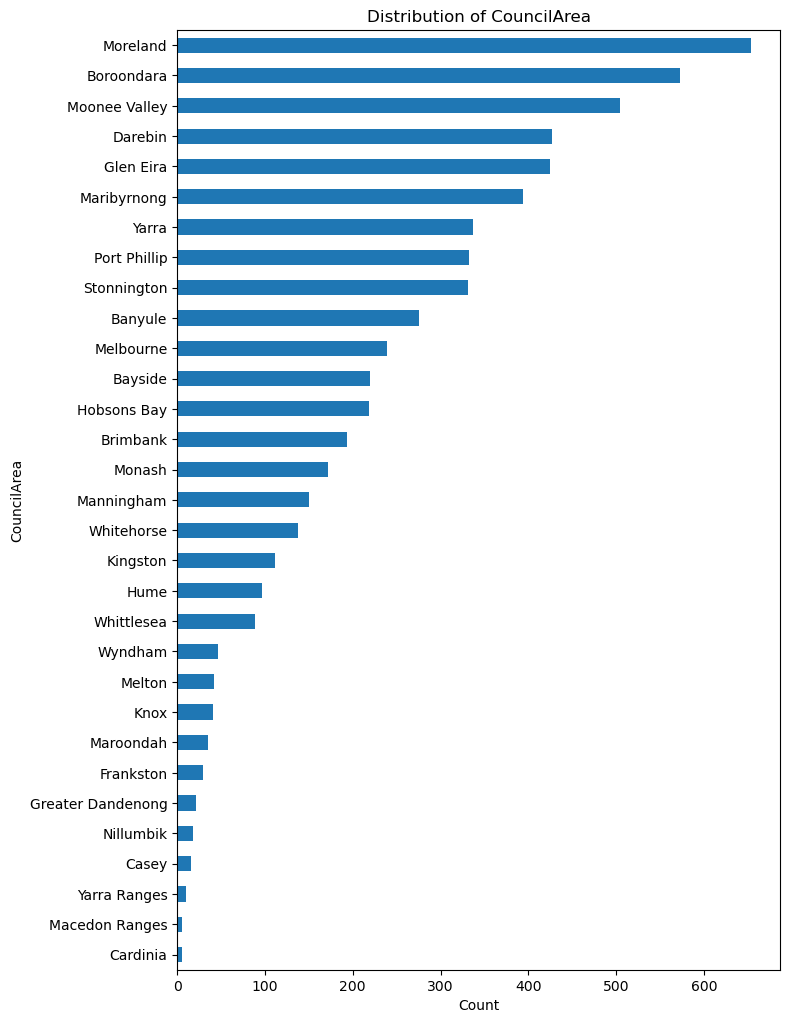

Analysis for column: Regionname

Frequency counts:
Regionname
Southern Metropolitan         2151
Northern Metropolitan         1841
Western Metropolitan          1383
Eastern Metropolitan           565
South-Eastern Metropolitan     156
Eastern Victoria                23
Northern Victoria               19
Western Victoria                14
Name: count, dtype: int64
Mode: ['Southern Metropolitan']

Unique categories: 8



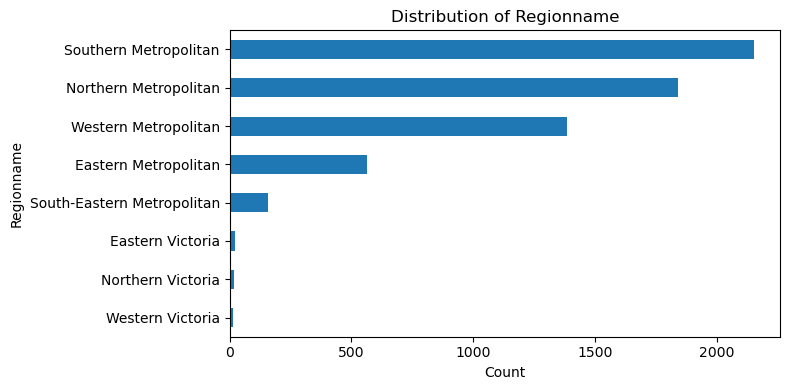

In [129]:
def categorical_summary(df, column):
    print(f'Analysis for column: {column}\n')

    freq = df[column].value_counts()
    print('Frequency counts:')
    print(freq)

    mode_categorical = df[column].mode()
    print(f'Mode: {mode_categorical.tolist()}')
    print()

    count_unique = df[column].nunique()
    print(f'Unique categories: {count_unique}\n')

    freq.sort_values(ascending=True).plot(kind='barh', figsize=(8, max(4, len(freq)/3)))
    plt.title(f'Distribution of {column}')
    plt.xlabel('Count')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    categorical_summary(house, col)

In [130]:
# Dropping YearBuilt outlier
house.drop(house[house['YearBuilt'] == 1196].index, inplace=True)

In [131]:
# Correlations
corr_matrix = house[numeric_cols].corr()
numeric_corr = corr_matrix['Price'].sort_values(ascending=False)
numeric_corr

Price           1.000000
BuildingArea    0.533507
Rooms           0.533337
Bedroom2        0.514071
Bathroom        0.503541
Car             0.261070
Longtitude      0.212097
Landsize        0.081149
Distance       -0.149453
Lattitude      -0.213400
Name: Price, dtype: float64

In [132]:
def chi_square(freq):
    total = freq.to_numpy().sum()
    expected = (freq.sum(axis=1).to_numpy().reshape(-1,1) *
                freq.sum(axis=0).to_numpy().reshape(1,-1)) / total
    chi2 = ((freq.to_numpy() - expected)**2 / expected).sum()
    return chi2

def categorical_corr(houses, categorical_cols, numeric_cols, bins=4):
    price_category = f'{numeric_cols}_category'
    houses[price_category] = pd.cut(houses[numeric_cols], bins=bins, labels=False)
    results = {}

    for col in categorical_cols:
        freq = pd.crosstab(houses[col], houses[price_category])
        chi2 = chi_square(freq)
        results[col] = chi2

    results_series = pd.Series(results)
    return results_series

categorical_corr(house, categorical_cols, 'Price')

Suburb         1645.843205
Type            150.283487
Postcode       1594.518692
YearBuilt      2935.272854
CouncilArea     747.196998
Regionname      363.886685
dtype: float64

BuildingArea
120.00    1.56%
100.00    1.28%
110.00    1.28%
130.00    1.24%
115.00    1.11%
          ...  
113.60    0.02%
66.32     0.02%
35.64     0.02%
61.60     0.02%
388.50    0.02%
Name: proportion, Length: 538, dtype: object


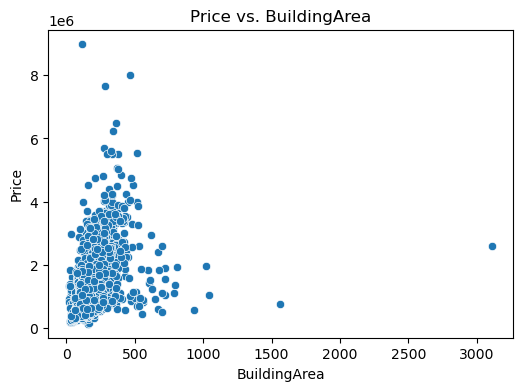

Rooms
3    40.92%
2    27.88%
4    20.71%
1     5.33%
5     4.55%
6     0.46%
7      0.1%
8     0.05%
Name: proportion, dtype: object


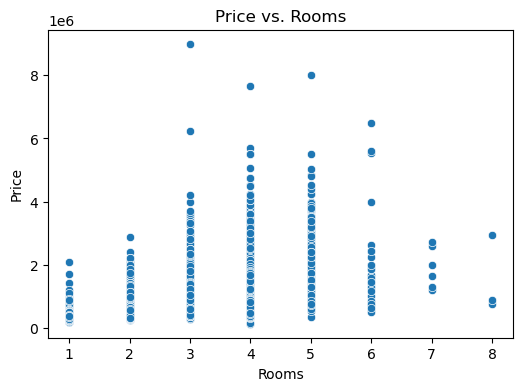

Bedroom2
3    41.05%
2    28.76%
4    19.83%
1     5.48%
5     4.23%
6     0.44%
0     0.08%
7     0.07%
9     0.05%
8     0.02%
Name: proportion, dtype: object


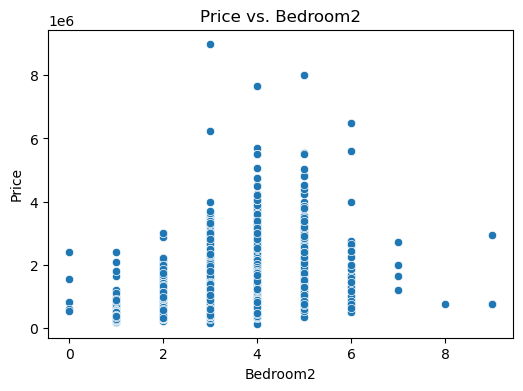

In [133]:
# Exploratory analysis

selected_cols = ['BuildingArea', 'Rooms', 'Bedroom2']

for col in selected_cols:
    if col == 'Price':
        continue
    prop = house[col].value_counts(normalize=True) * 100
    print(prop.round(2).astype(str) + '%')

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='Price', data=house)
    plt.title(f'Price vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

YearBuilt
1970.0    9.67%
1960.0    8.94%
1950.0    7.36%
1900.0    4.37%
1930.0    3.77%
          ...  
1902.0    0.02%
1907.0    0.02%
1906.0    0.02%
1964.0    0.02%
2018.0    0.02%
Name: proportion, Length: 133, dtype: object


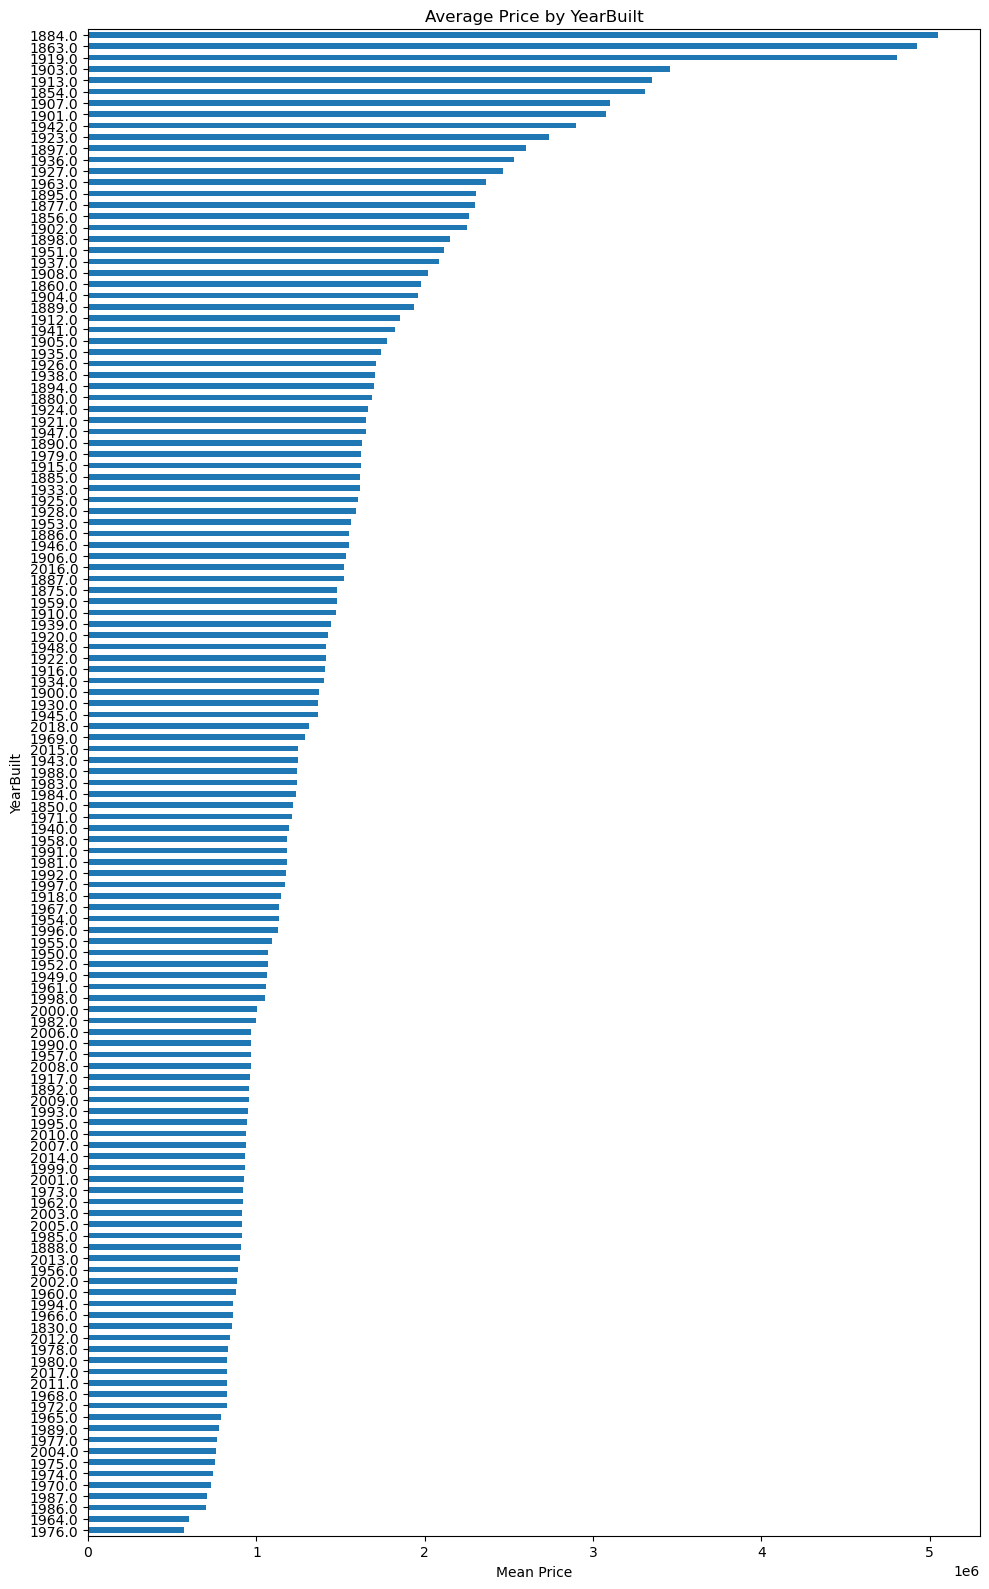

Suburb
Reservoir         8.04%
Richmond          7.25%
Brunswick         6.56%
Bentleigh East    5.61%
Coburg            5.34%
Essendon          5.24%
Preston           5.19%
Hawthorn          5.03%
Yarraville        4.66%
Pascoe Vale        4.6%
St Kilda          4.55%
Glen Iris         4.44%
Glenroy           4.44%
Moonee Ponds      4.29%
South Yarra       4.29%
Carnegie          4.23%
Footscray         4.23%
Kew               4.02%
Elwood            4.02%
Brighton          3.97%
Name: proportion, dtype: object


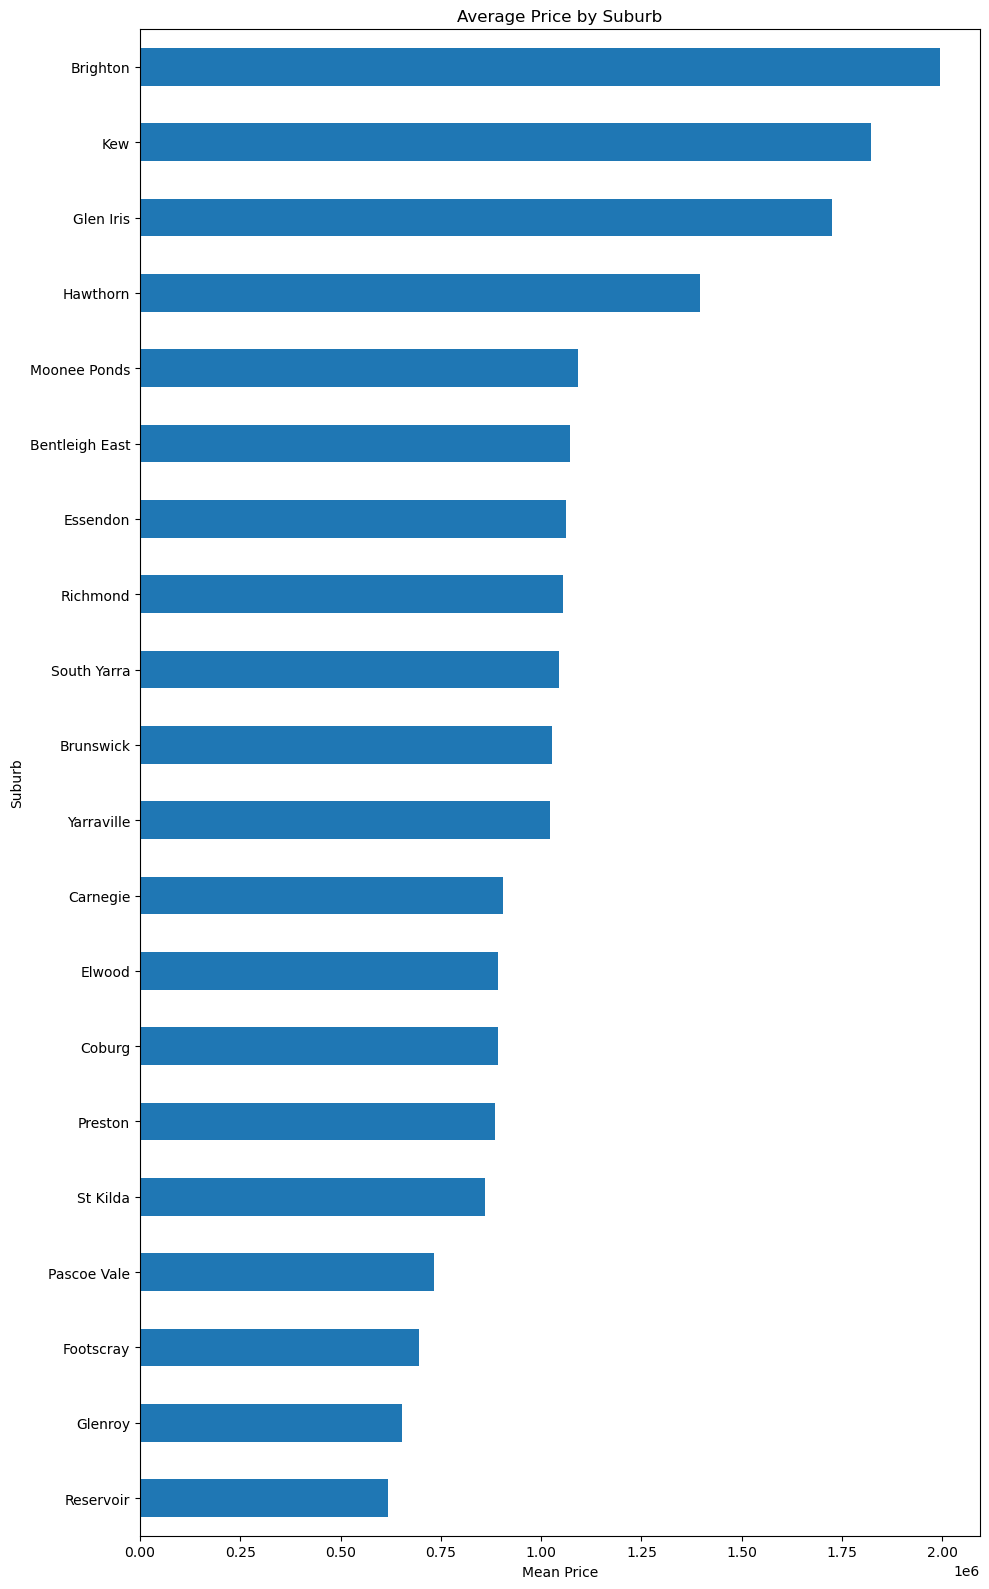

In [134]:
selected_cols = ['YearBuilt', 'Suburb']

for col in selected_cols:
    if col == 'Price':
        continue

    if col == 'YearBuilt': # Because the one outlier keeps showing up
        plot_data = house[house['YearBuilt'] != 1196].copy()
        plot_data['YearBuilt'] = plot_data['YearBuilt'].cat.remove_unused_categories()
    elif col == 'Suburb':
        top = house[col].value_counts().nlargest(20).index
        plot_data = house[house[col].isin(top)]
    else:
        plot_data = house

    prop = plot_data[col].value_counts(normalize=True) * 100
    print(prop.round(2).astype(str) + '%')

    mean_price = plot_data.groupby(col, observed=True)['Price'].mean().sort_values()
    plt.figure(figsize=(10, 16))
    mean_price.plot(kind='barh')
    plt.title(f'Average Price by {col}')
    plt.xlabel('Mean Price')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Data Mining**

In [135]:
#X
h = house
h1 = pd.get_dummies( h, drop_first=True)
# Replacing NaN values with 0
X =  h1.fillna(0)


In [136]:
from sklearn.model_selection import train_test_split

#categorical variable
#Create a random 80/20 split
#creating the split
x_train, x_test = train_test_split(X, test_size = 0.20, random_state = 7)


In [137]:
print(x_train.shape)
print(x_test.shape)

(4920, 653)
(1231, 653)


In [138]:
#Target Variable
y_train = x_train['Price']
#Target Variable
y_test = x_test['Price']

rf01 = RandomForestRegressor(n_estimators = 100, min_samples_leaf = 10, max_depth = 5).fit(x_train, y_train)
predict = rf01.predict(x_test)

In [139]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predict)
print('r2 score for perfect model is', r2)
#https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/
error = mae(y_test, predict)
print("Mean absolute error : " + str(error))
#source: https://www.geeksforgeeks.org/python/how-to-calculate-mean-absolute-error-in-python/

r2 score for perfect model is 0.9868535317388073
Mean absolute error : 9256.145837178488


Regionname
Eastern Metropolitan          0.091692
Eastern Victoria              0.003739
Northern Metropolitan         0.299301
Northern Victoria             0.003089
South-Eastern Metropolitan    0.025362
Southern Metropolitan         0.349699
Western Metropolitan          0.224841
Western Victoria              0.002276
Name: count, dtype: float64


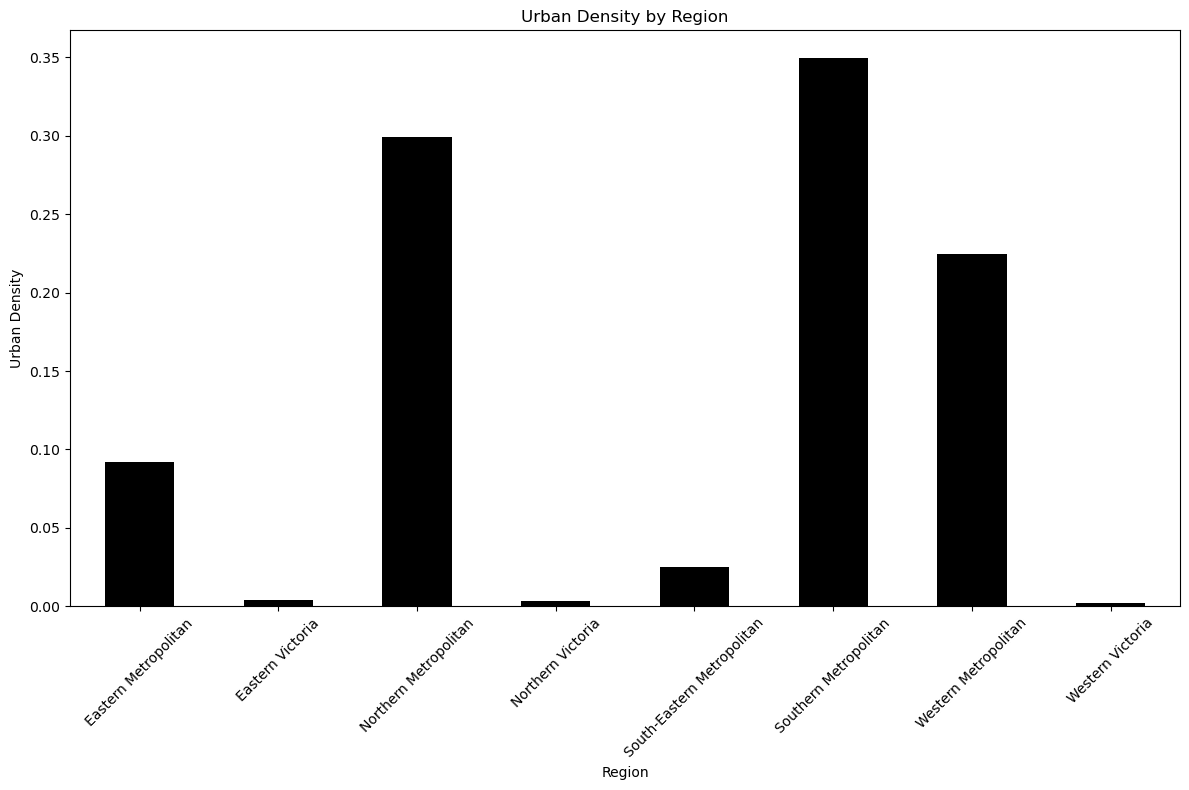

In [140]:
homes = house.groupby('Regionname')['Regionname'].value_counts()
urban_density = homes / homes.sum()
print(urban_density)
urban_density.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='gist_earth')
plt.title("Urban Density by Region")
plt.xlabel("Region")
plt.ylabel("Urban Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [141]:
cart01 = DecisionTreeClassifier(criterion = "gini", max_leaf_nodes=30).fit(x_train, y_train)

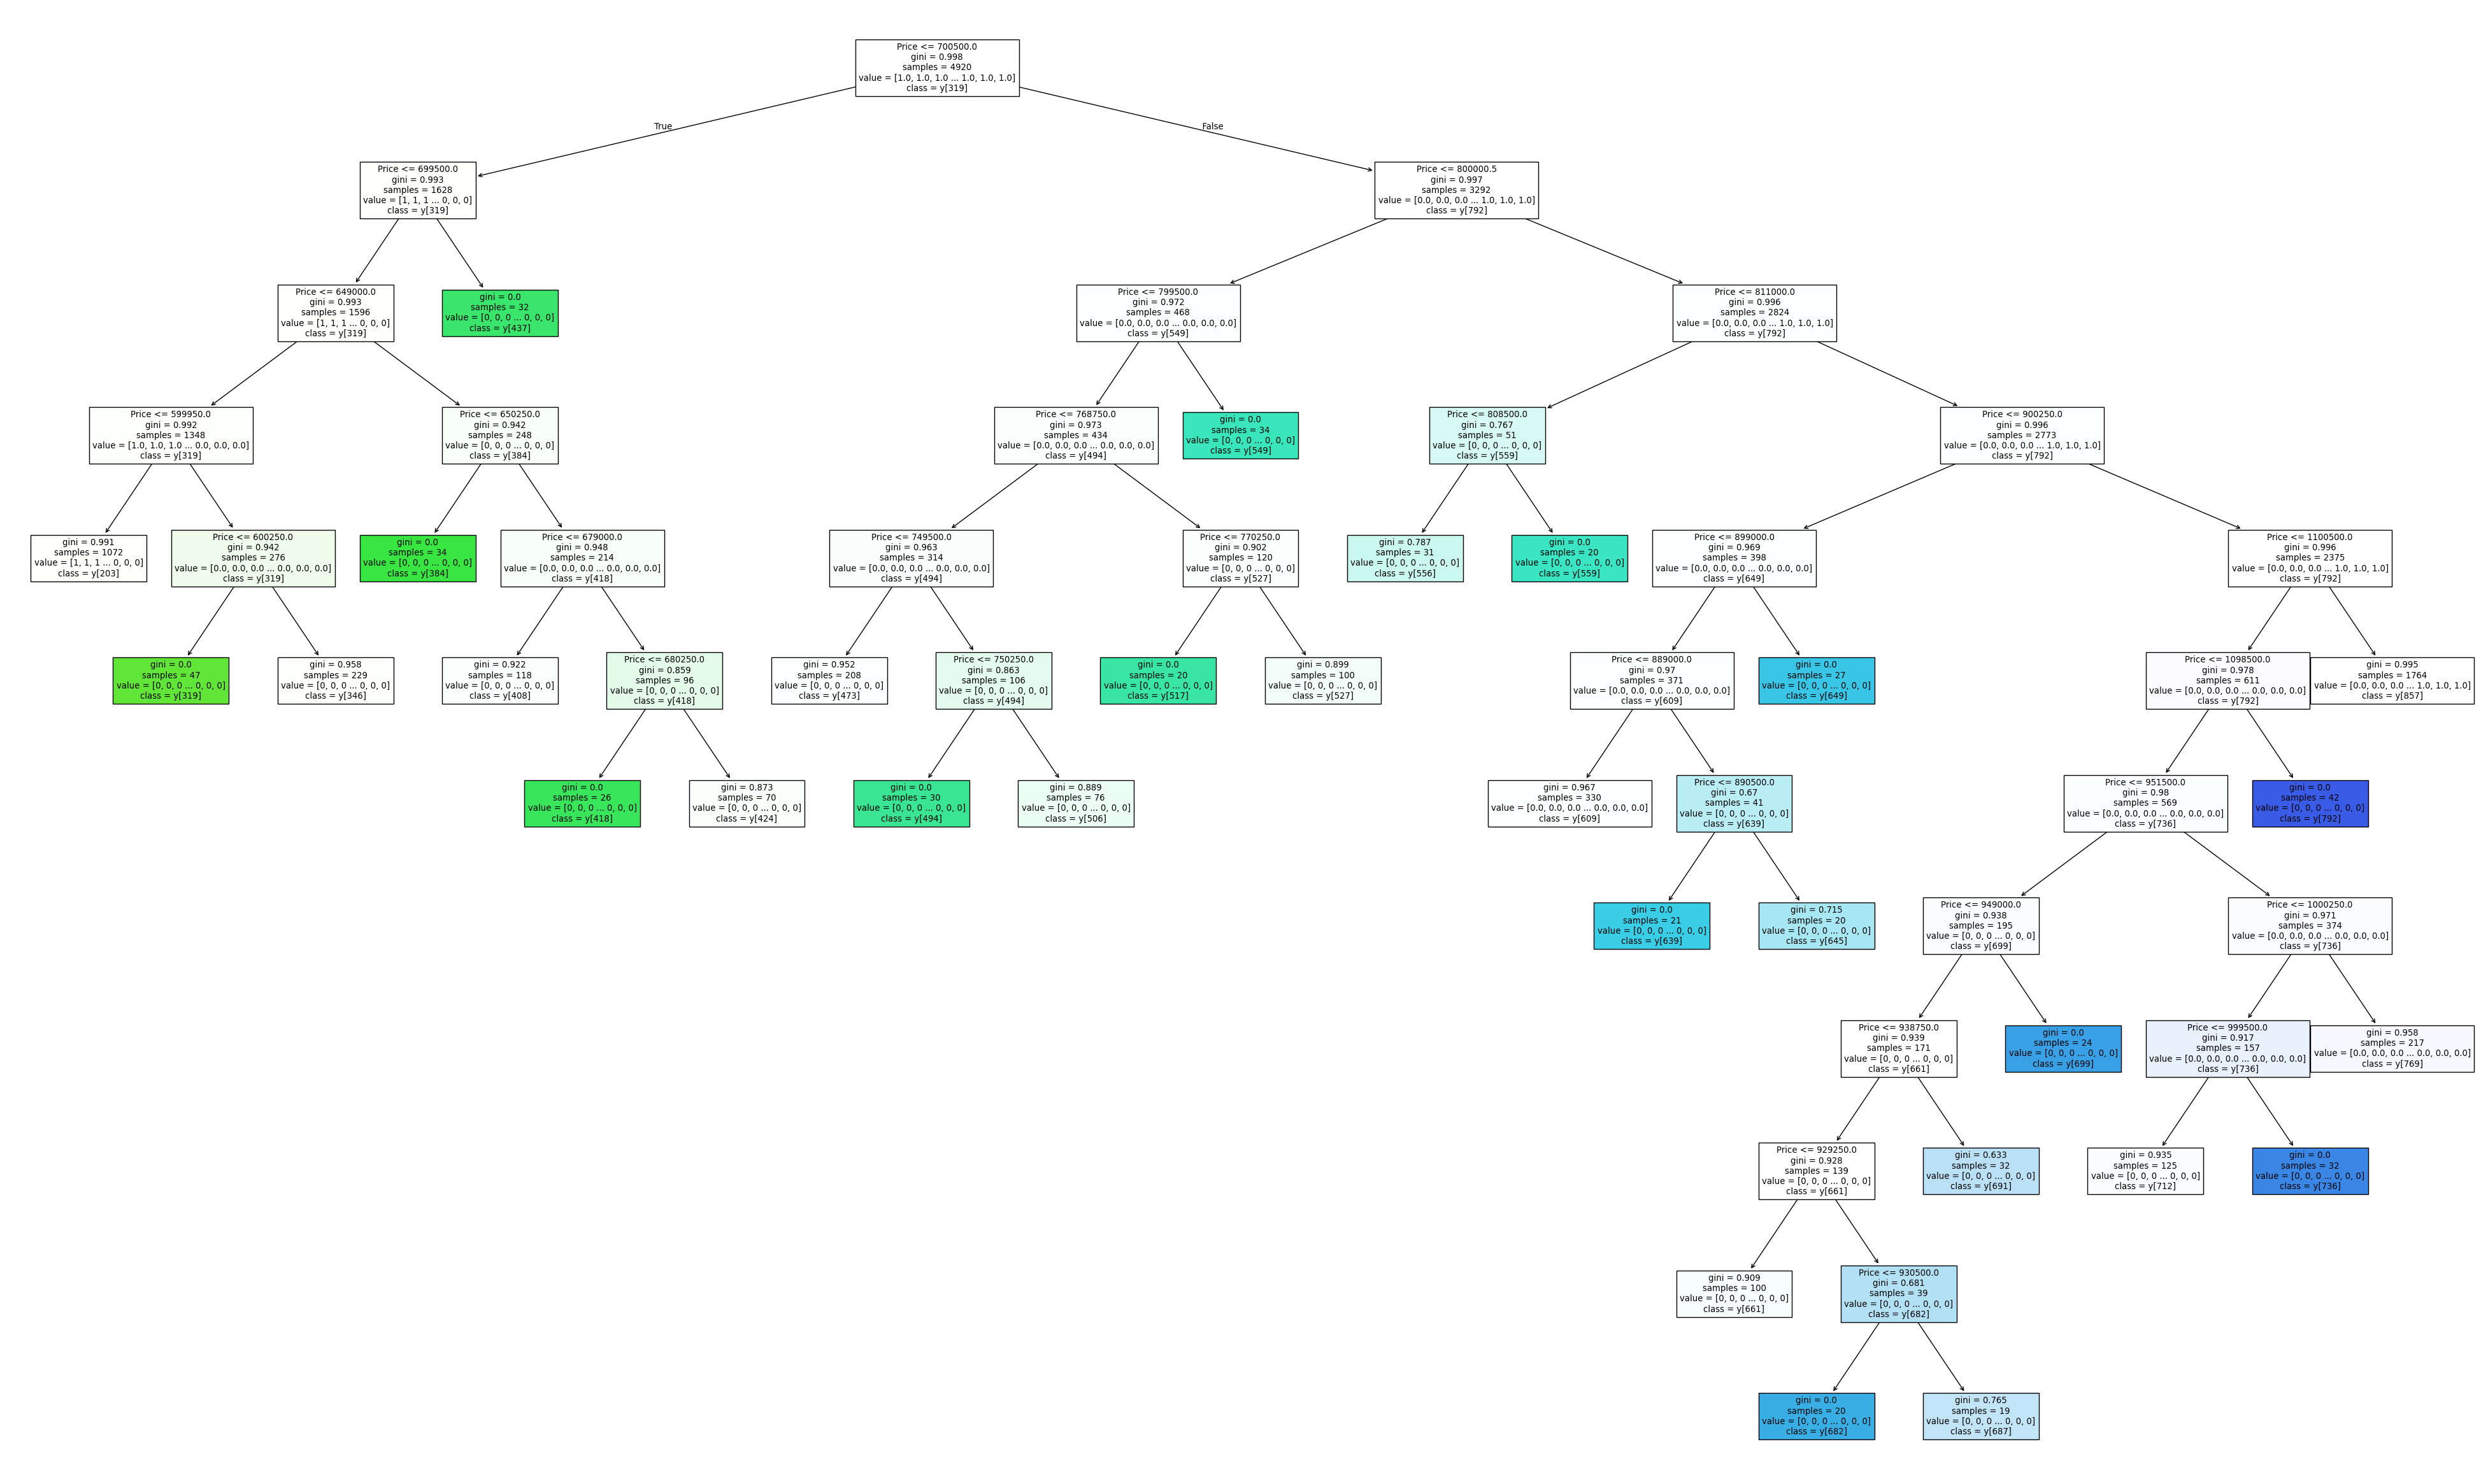

In [142]:
# Custom color function applied to nodes
fig, ax = plt.subplots(figsize=(50,30))
tree.plot_tree(cart01,
               feature_names=x_train.columns,
               class_names=True,
               filled=True,
               ax=ax)  # plot_tree doesn't directly support custom node functions, so this step remains simple
plt.show()
#source:
#https://www.geeksforgeeks.org/machine-learning/changing-colors-for-decision-tree-plot-using-sklearn-plot-tree/

In [143]:
# Create price/sq.ft. feature
house['price_per_sqft'] = house['Price'] / house['BuildingArea']

house = house.dropna(subset=['Price', 'BuildingArea', 'Regionname'])
house = house[house['BuildingArea'] > 0]

print(house.groupby('Regionname')['price_per_sqft'].describe())

                             count         mean          std          min  \
Regionname                                                                  
Eastern Metropolitan         564.0  7341.484536  3951.680130  1394.169835   
Eastern Victoria              23.0  4444.587310  1642.570167   786.618445   
Northern Metropolitan       1841.0  7710.415081  3182.126532   621.520343   
Northern Victoria             19.0  3838.216684  1783.272057  2275.641026   
South-Eastern Metropolitan   156.0  6328.217958  6045.683586  1985.600000   
Southern Metropolitan       2151.0  9520.197005  4136.447958   474.695708   
Western Metropolitan        1383.0  6552.169669  3214.775651   707.142857   
Western Victoria              14.0  2741.956477   730.080113  1600.000000   

                                    25%          50%           75%  \
Regionname                                                           
Eastern Metropolitan        5469.607843  6657.578947   8245.062739   
Eastern Victoria   

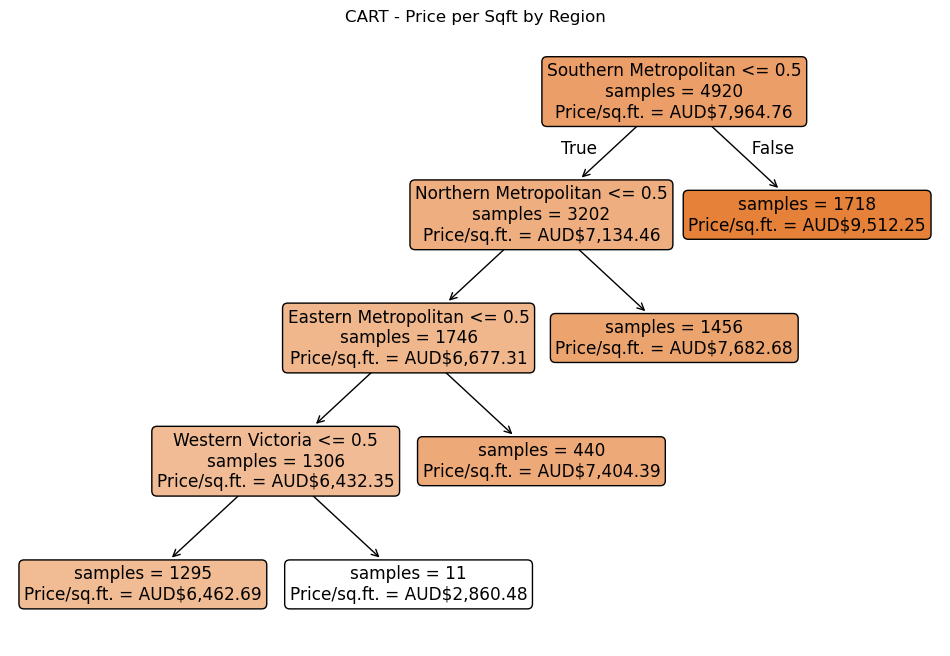

In [146]:
from sklearn.tree import plot_tree
import re


# CART
X = pd.get_dummies(house['Regionname'])
y_reg = house['price_per_sqft']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

cart = DecisionTreeRegressor(max_depth=4, random_state=42)
cart.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(cart, feature_names=X.columns.tolist(), filled=True, rounded=True, impurity=False)
plt.title("CART - Price per Sqft by Region")

for text_obj in plt.gca().texts:
    updated = text_obj.get_text().replace("value =", "Price/sq.ft. =")
    updated = re.sub(r"Price/sq.ft. = (\d+\.\d+)",
                     lambda m: f"Price/sq.ft. = AUD${float(m.group(1)):,.2f}",
                     updated)
    text_obj.set_text(updated)

plt.show()

In [147]:
# Naive-Bayes
house['price_tier'] = pd.qcut(house['price_per_sqft'], q=3, labels=['Low', 'Medium', 'High'])

t1 = pd.crosstab(house['Regionname'], house['price_tier'])
t1['Total'] = t1.sum(axis=1)
t1.loc['Total'] = t1.sum()
t1


price_tier,Low,Medium,High,Total
Regionname,,,,
Eastern Metropolitan,246,196,122,564
Eastern Victoria,21,2,0,23
Northern Metropolitan,679,579,583,1841
Northern Victoria,18,0,1,19
South-Eastern Metropolitan,101,37,18,156
Southern Metropolitan,239,812,1100,2151
Western Metropolitan,733,424,226,1383
Western Victoria,14,0,0,14
Total,2051,2050,2050,6151


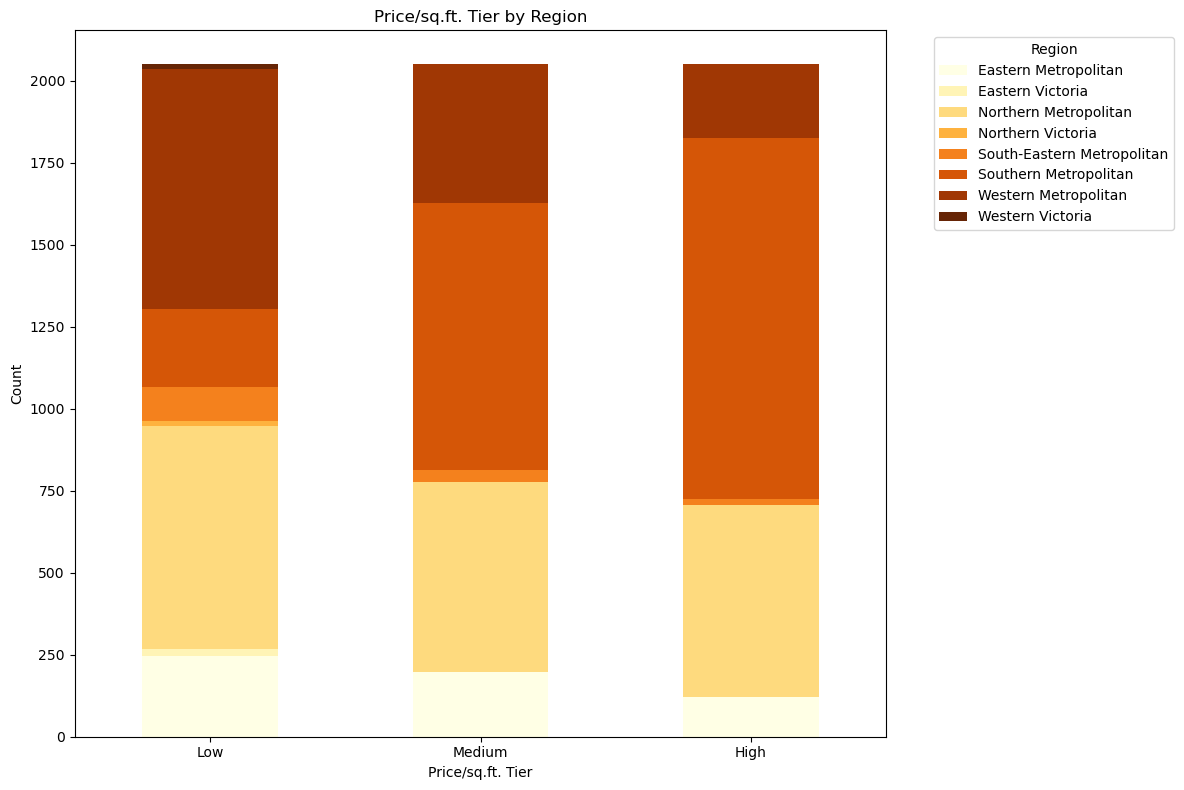

In [148]:
t1_plot = pd.crosstab(house['price_tier'], house['Regionname'])
t1_plot.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='YlOrBr')
plt.title("Price/sq.ft. Tier by Region")
plt.xlabel("Price/sq.ft. Tier")
plt.ylabel("Count")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [149]:
X_price_ind = pd.get_dummies(house['price_tier'], drop_first=True).astype(float)
X_price_ind_dict = {i: col for i, col in enumerate(X_price_ind.columns)}

X_region_ind = pd.get_dummies(house['Regionname'], drop_first=True).astype(float)
X_region_ind_dict = {i: col for i, col in enumerate(X_region_ind.columns)}

X = pd.concat((X_price_ind, X_region_ind), axis=1)

print("Price tier mapping:", X_price_ind_dict)
print("Region mapping:", X_region_ind_dict)

Price tier mapping: {0: 'Medium', 1: 'High'}
Region mapping: {0: 'Eastern Victoria', 1: 'Northern Metropolitan', 2: 'Northern Victoria', 3: 'South-Eastern Metropolitan', 4: 'Southern Metropolitan', 5: 'Western Metropolitan', 6: 'Western Victoria'}


In [150]:
Y = house['price_tier']
X_train, X_test = train_test_split(X, test_size = 0.20, random_state = 42)
Y_train, Y_test = train_test_split(Y, test_size = 0.20, random_state = 42)

nb_01 = MultinomialNB().fit(X_train, Y_train)

Y_predicted = nb_01.predict(X_test)
Y_predicted = pd.crosstab(Y_test, Y_predicted, rownames=['Actual'], colnames=['Predicted']) #simplified with the help of Gemini AI
# Reverse the order of rows
Y_predicted = Y_predicted.iloc[::-1] #assisted by Gemini AI
Y_predicted['Total'] = Y_predicted.sum(axis=1); Y_predicted.loc['Total'] = Y_predicted.sum()
# Reorder columns to switch 'High' and 'Low'
new_column_order = ['High', 'Medium', 'Low', 'Total']  #assisted by Gemini AI
Y_predicted = Y_predicted[new_column_order] #assisted by Gemini AI

Y_predicted

Predicted,High,Medium,Low,Total
Actual,,,,
High,423,0,0,423
Medium,0,404,0,404
Low,46,0,358,404
Total,469,404,358,1231


A near perfect diagonal. This model has proven effective a